# 04_claim_parser_dev.ipynb

> Develop the claim extraction pipeline
> Generates a small pilot set of explanations, builds the LLM-based extractor
> that converts free-text narratives into structured claims of the form
> (feature, direction, rank), and measures the extractor's own reproducibility
> before it is validated against human coding in 05.
> A rule-based parser was trialled in an earlier iteration and abandoned.
> Encoded one-hot feature names such as Contract_Two_year appear in narratives
> as "a two-year contract", and matching them by rule required dataset-specific
> synonym lists that had to be tuned against the pilot itself. That tuning
> fitted the parser to the very data on which it would later be validated, and
> its recall never exceeded roughly one third of the supplied drivers. The LLM
> extractor recovered almost every supplied driver without such tuning, so it
> is used alone. The cost of that choice is that extraction is not perfectly
> deterministic, which is why the stability check below exists.

Loaded credentials from C:\Users\User\Downloads\same-case-different-reasons\project\.env
Evidence blocks available: 3,600
Pilot blocks selected: 120 across 12 strata
Saved: prompts/basic_v1.txt
Saved: prompts/constrained_v1.txt
Saved: prompts/verification_v1.txt
Subject: a subscriber
Assessment: the likelihood that the subscriber will leave the service
Assessed value: 0.476 (typical value for this population: 0.265)

Factors that drove this assessment, most influential first:
  1. Contract_Two_year — raised the assessment (relative weight 0.30)
  2. tenure — raised the assessment (relative weight 0.23)
  3. InternetService_Fiber_optic — lowered the assessment (relative weight 0.19)
  4. Contract_One_year — raised the assessment (relative weight 0.15)
  5. MonthlyCharges — lowered the assessment (relative weight 0.13)
  20/120 blocks (0s)
  40/120 blocks (0s)
  60/120 blocks (0s)
  80/120 blocks (0s)
  100/120 blocks (0s)
  120/120 blocks (0s)
Pilot narratives: 360

Example output:

- T

,N narratives,Runs each,Identical across runs,Feature Jaccard,Direction agreement
0,50,3,0.58,1.0,1.0


Saved: tab10_pilot_fidelity.csv


,domain,prompt,n,omission,hallucination,direction_agreement,direction_unresolved
0,churn,basic,60,0.1000,0.0,0.9892,0.0100
1,churn,constrained,60,0.0000,0.0,1.0000,0.0000
2,churn,verification,60,0.0467,0.0,1.0000,0.0108
3,credit,basic,60,0.1233,0.0,0.9933,0.0033
4,credit,constrained,60,0.0000,0.0,1.0000,0.0000
5,credit,verification,60,0.0267,0.0,1.0000,0.0100


Saved: tab11_extraction_diagnostics.csv


,Feature,Missed,Invented,Total
11,loan_grade_D,20,0,20
12,Contract_Two_year,18,0,18
10,Contract_One_year,16,0,16
14,loan_grade_E,7,0,7
6,loan_grade_G,6,0,6
9,loan_grade_F,5,0,5
7,InternetService_Fiber_optic,4,0,4
8,InternetService_No,3,0,3
2,person_home_ownership_OWN,3,0,3
1,PaymentMethod_Electronic_check,2,0,2


Saved: fig10_pilot_fidelity_by_prompt.png / fig10_pilot_fidelity_by_prompt.pdf


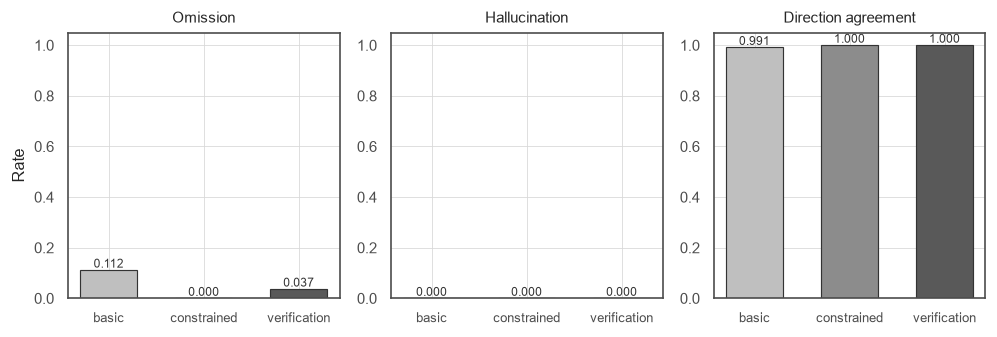

Saved: fig11_extractor_stability.png / fig11_extractor_stability.pdf


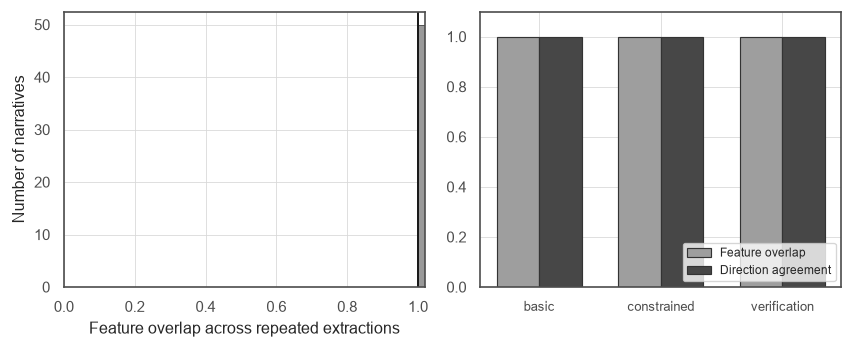

Saved: manual_coding_sheet.csv (300 rows)
domain  prompt      
churn   basic           50
        constrained     50
        verification    50
credit  basic           50
        constrained     50
        verification    50
Saved: coding_auto_reference.csv  (for 05 only, do not give to coders)
Saved: extractor_config.json
Saved: logs/04_run_20260911.json
Artefacts produced:
  extractor_config.json                 2.0 KB
  pilot_extractions.json              853.8 KB
  extractor_stability.json            156.7 KB
  manual_coding_sheet.csv             205.9 KB
  coding_auto_reference.csv            86.3 KB

Pilot generations cached: 360 files

Extractor summary
-----------------
Claims per supplied driver   0.95
Identical across 3 runs      0.58
Feature overlap across runs  1.0
Direction agreement          1.0

Before running 05_parser_validation
  1. Review tab11_extraction_diagnostics. If a feature is systematically
     missed or invented, adjust the prompt or the allowed-feature lis

In [1]:
# ============================================================================
# 04_claim_parser_dev.ipynb
# Develop the claim extraction pipeline
# Generates a small pilot set of explanations, builds the LLM-based extractor
# that converts free-text narratives into structured claims of the form
# (feature, direction, rank), and measures the extractor's own reproducibility
# before it is validated against human coding in 05.
#
# A rule-based parser was trialled in an earlier iteration and abandoned.
# Encoded one-hot feature names such as Contract_Two_year appear in narratives
# as "a two-year contract", and matching them by rule required dataset-specific
# synonym lists that had to be tuned against the pilot itself. That tuning
# fitted the parser to the very data on which it would later be validated, and
# its recall never exceeded roughly one third of the supplied drivers. The LLM
# extractor recovered almost every supplied driver without such tuning, so it
# is used alone. The cost of that choice is that extraction is not perfectly
# deterministic, which is why the stability check below exists.
# ============================================================================


# [Cell 1] Imports and global configuration
import os
import re
import json
import time
import hashlib
import warnings
from pathlib import Path
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

ROOT = Path("..")
DATA_DIR = ROOT / "data"
PROMPT_DIR = ROOT / "prompts"
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"
LOG_DIR = ROOT / "logs"

for d in [DATA_DIR, PROMPT_DIR, FIG_DIR, TAB_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PILOT_DIR = DATA_DIR / "pilot_generations"
PILOT_DIR.mkdir(parents=True, exist_ok=True)

# API keys are read from a .env file at the project root rather than being
# written into the notebook, so that the code can be published unchanged.
from dotenv import load_dotenv, find_dotenv

_env = find_dotenv(usecwd=True)
if not _env:
    raise FileNotFoundError("No .env found at the project root")
load_dotenv(_env)
print(f"Loaded credentials from {_env}")


# [Cell 2] Plotting style: grayscale, publication settings
sns.set_theme(style="whitegrid", context="paper")
sns.set_palette(sns.color_palette("gray", n_colors=8))

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "font.family": "sans-serif",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.5,
    "axes.edgecolor": "0.3",
    "axes.labelcolor": "0.15",
    "text.color": "0.15",
    "xtick.color": "0.3",
    "ytick.color": "0.3",
    "image.cmap": "gray",
    "savefig.bbox": "tight",
    "savefig.transparent": False,
})


def save_fig(fig, name):
    """Save a figure as both PNG and PDF at 600 dpi. No caption is added."""
    for ext in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=600, bbox_inches="tight")
    print(f"Saved: {name}.png / {name}.pdf")


def save_table(df, name, index=False):
    """Save a table as CSV under results/tables."""
    df.to_csv(TAB_DIR / f"{name}.csv", index=index, encoding="utf-8-sig")
    print(f"Saved: {name}.csv")


# [Cell 3] Pilot configuration
# The pilot exists to provide realistic narrative text on which the extractor
# can be developed and its reproducibility measured, before the full run in 07.
PILOT_MODEL = "gpt-5.4-mini"    # generator used for extractor development
PILOT_N_BLOCKS = 120            # evidence blocks sampled for the pilot
PILOT_TEMPERATURE = 1.0

# The extractor is the measurement instrument for the entire study, so a
# higher tier is used here than for generation. If the stability and
# validity checks below fall short, raise it further rather than economising.
EXTRACTOR_MODEL = "gpt-5.6-terra"
EXTRACTOR_TEMPERATURE = None    # gpt-5.6 rejects any explicit temperature
EXTRACTOR_SEED = 42             # the vendor's determinism control, used instead

# Extractor reproducibility check
STABILITY_SAMPLE = 50           # narratives re-extracted
STABILITY_N = 3                 # extractions per narrative

MAX_WORDS = 150                 # narrative length cap
TOP_K = 5
CANDIDATE_CAP = 40              # allowed-feature list length passed to the extractor

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])


# [Cell 4] Load evidence blocks and feature registry
with open(DATA_DIR / "evidence_blocks.json", encoding="utf-8") as f:
    evidence_blocks = json.load(f)

with open(DATA_DIR / "feature_registry.json", encoding="utf-8") as f:
    feature_registry = json.load(f)

print(f"Evidence blocks available: {len(evidence_blocks):,}")

# Sample a pilot subset spanning both domains and all model / XAI combinations
blocks_df = pd.DataFrame([
    {"idx": i, "domain": b["domain"], "model": b["model"], "xai": b["xai"]}
    for i, b in enumerate(evidence_blocks)
])
n_strata = len(blocks_df.groupby(["domain", "model", "xai"]))

pilot_idx = (
    blocks_df.groupby(["domain", "model", "xai"], group_keys=False)
    .apply(lambda g: g.sample(
        n=max(1, PILOT_N_BLOCKS // n_strata), random_state=SEED
    ))["idx"].tolist()
)
pilot_blocks = [evidence_blocks[i] for i in pilot_idx]
print(f"Pilot blocks selected: {len(pilot_blocks)} across {n_strata} strata")


# [Cell 5] Prompt templates
# Three prompt conditions are used in the main study. They are written to disk
# so that the exact text used in any run can be recovered later.
SYSTEM_PROMPT = f"""You are explaining the output of a predictive model to a non-technical reader.

The reader has no background in statistics or machine learning. They need to understand:
- why the model produced this assessment, and
- which factors drove it.

OUTPUT RULES
- Write at most {TOP_K} short bullet points.
- Keep the whole response under {MAX_WORDS} words.
- Use plain language.
- Do not mention SHAP, LIME, or any technical method name.
- Do not reveal code or numeric attribution values."""

PROMPT_VARIANTS = {
    "basic": "",
    "constrained": (
        "\n\nADDITIONAL REQUIREMENTS\n"
        "- Mention every factor listed in the evidence, and no others.\n"
        "- For each factor, state clearly whether it raised or lowered the assessment.\n"
        "- Preserve the order in which the factors are listed."
    ),
    "verification": (
        "\n\nADDITIONAL REQUIREMENTS\n"
        "- Before writing, check each factor's stated direction in the evidence.\n"
        "- Do not introduce any factor that is absent from the evidence.\n"
        "- After drafting, verify that every direction you wrote matches the evidence."
    ),
}

for name, extra in PROMPT_VARIANTS.items():
    (PROMPT_DIR / f"{name}_v1.txt").write_text(SYSTEM_PROMPT + extra, encoding="utf-8")
    print(f"Saved: prompts/{name}_v1.txt")


# [Cell 6] Build the user message from an evidence block
DOMAIN_FRAMING = {
    "credit": {
        "subject": "a loan applicant",
        "outcome": "the likelihood that the loan will not be repaid",
    },
    "churn": {
        "subject": "a subscriber",
        "outcome": "the likelihood that the subscriber will leave the service",
    },
}


def build_user_message(block):
    """Render the structured evidence block as the user-facing prompt text."""
    framing = DOMAIN_FRAMING[block["domain"]]
    lines = [
        f"Subject: {framing['subject']}",
        f"Assessment: {framing['outcome']}",
        f"Assessed value: {block['predicted_probability']:.3f} "
        f"(typical value for this population: {block['base_value']:.3f})",
        "",
        "Factors that drove this assessment, most influential first:",
    ]
    for d in block["drivers"]:
        verb = "raised" if d["direction"] == "increases" else "lowered"
        lines.append(
            f"  {d['rank']}. {d['feature']} — {verb} the assessment "
            f"(relative weight {abs(d['contribution_norm']):.2f})"
        )
    return "\n".join(lines)


print(build_user_message(pilot_blocks[0]))


# [Cell 7] Pilot generation with caching
def block_key(block, prompt_name, repeat, model, temperature):
    """Stable identifier used for cache filenames."""
    raw = (f"{block['domain']}|{block['model']}|{block['xai']}|{block['case_id']}"
           f"|{prompt_name}|{repeat}|{model}|{temperature}")
    return hashlib.md5(raw.encode()).hexdigest()[:16]


def generate_one(block, prompt_name, repeat, model, temperature, cache_dir):
    """Generate a single narrative, reusing the cached result when present."""
    key = block_key(block, prompt_name, repeat, model, temperature)
    path = cache_dir / f"{key}.json"
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))

    system = (PROMPT_DIR / f"{prompt_name}_v1.txt").read_text(encoding="utf-8")
    user = build_user_message(block)

    resp = client.chat.completions.create(
        model=model,
        temperature=temperature,
        messages=[
            {"role": "system", "content": system},
            {"role": "user", "content": user},
        ],
    )

    record = {
        "domain": block["domain"],
        "model": block["model"],
        "xai": block["xai"],
        "case_id": block["case_id"],
        "prompt": prompt_name,
        "repeat": repeat,
        "llm": model,
        "temperature": temperature,
        "explanation": resp.choices[0].message.content.strip(),
        "evidence": block["drivers"],
        "timestamp": pd.Timestamp.now().isoformat(),
    }
    path.write_text(json.dumps(record, ensure_ascii=False, indent=1), encoding="utf-8")
    return record


pilot_records = []
t0 = time.time()

for i, block in enumerate(pilot_blocks, 1):
    for prompt_name in PROMPT_VARIANTS:
        rec = generate_one(
            block, prompt_name, repeat=1,
            model=PILOT_MODEL, temperature=PILOT_TEMPERATURE,
            cache_dir=PILOT_DIR,
        )
        pilot_records.append(rec)
    if i % 20 == 0:
        print(f"  {i}/{len(pilot_blocks)} blocks ({time.time() - t0:.0f}s)")

print(f"Pilot narratives: {len(pilot_records)}")
print("\nExample output:\n")
print(pilot_records[0]["explanation"])


# [Cell 8] Candidate feature list
# The extractor is given a closed list of identifiers to choose from, which is
# what makes its output comparable across generations. The list contains more
# than the supplied drivers, so that a narrative introducing an unsupplied
# feature is detectable rather than silently dropped.
#
# The supplied drivers are placed first and the list is capped, because a very
# long allowed-feature list degrades extraction and inflates prompt cost.
def candidates_for(domain, evidence, cap=CANDIDATE_CAP):
    """Supplied drivers first, then other domain features, capped in length."""
    supplied = [d["feature"] for d in evidence]
    others = [f for f in feature_registry[domain]["features"] if f not in supplied]
    return (supplied + others)[:cap]


example = pilot_records[0]
cands = candidates_for(example["domain"], example["evidence"])
print(f"Allowed features passed to the extractor: {len(cands)}")
print("  supplied :", [d["feature"] for d in example["evidence"]])
print("  plus     :", cands[len(example["evidence"]):len(example["evidence"]) + 6], "...")


# [Cell 9] The extractor
# Direction is defined as the effect on the assessment, not as the level of the
# feature. "Low income raised the risk" is an increasing contribution, because
# income pushed the assessment upward. This distinction is stated explicitly in
# the prompt because it is the single most common source of extraction error.
EXTRACTOR_SYSTEM = """You convert an explanation into structured claims.

Read the explanation and list every factor it mentions as influencing the assessment.

For each factor return:
- feature: the exact identifier from the ALLOWED FEATURES list that the factor refers to.
           Match on meaning, not on wording: a narrative saying "a two-year contract"
           refers to the identifier Contract_Two_year.
           If the factor matches none of the allowed features, return the literal
           string OUT_OF_LIST.
- direction: "increases" if the factor pushed the assessment upward,
             "decreases" if it pushed the assessment downward,
             "unclear" if the explanation does not say.
- rank: the order of first mention, starting at 1.
- evidence_text: the exact sentence or bullet the factor came from.

Rules:
- Report only factors the explanation actually mentions.
- Do not infer factors from background knowledge.
- Direction refers to the effect on the assessment, not to whether the feature
  value is high or low. "Low income raised the risk" is direction=increases.
- Do not report the same identifier twice.
- Return JSON only, with no surrounding text or code fences."""


def normalise_claims(claims):
    """Clean the raw extractor output into a canonical claim list."""
    seen, out = set(), []
    for c in claims:
        feat = c.get("feature")
        if not feat or feat == "OUT_OF_LIST" or feat in seen:
            continue
        seen.add(feat)
        direction = c.get("direction")
        out.append({
            "feature": feat,
            "direction": direction if direction in ("increases", "decreases") else None,
            "rank": c.get("rank"),
            "evidence_text": str(c.get("evidence_text", ""))[:300],
        })

    out.sort(key=lambda x: (x["rank"] is None, x["rank"]))
    for i, c in enumerate(out, 1):
        c["rank"] = i
    return out


def extract_claims(text, allowed_features, model=EXTRACTOR_MODEL,
                   temperature=EXTRACTOR_TEMPERATURE, retries=3):
    """Extract structured claims from a narrative, constrained to a feature list.

    A failed extraction is raised rather than returned as an empty list. Silent
    failure would look identical to a narrative that mentioned nothing, and
    would propagate through every downstream metric as a valid measurement.
    """
    user = (
        "ALLOWED FEATURES:\n"
        + "\n".join(f"- {f}" for f in allowed_features)
        + "\n\nEXPLANATION:\n" + text
        + '\n\nReturn JSON: {"claims": [{"feature": ..., "direction": ..., '
          '"rank": ..., "evidence_text": ...}]}'
    )

    # Newer models reject an explicit temperature and renamed the token cap.
    # Determinism is requested through seed instead, which is the control the
    # vendor actually offers.
    kwargs = dict(
        model=model,
        response_format={"type": "json_object"},
        max_completion_tokens=1500,
        seed=EXTRACTOR_SEED,
        messages=[
            {"role": "system", "content": EXTRACTOR_SYSTEM},
            {"role": "user", "content": user},
        ],
    )
    if temperature is not None:
        kwargs["temperature"] = temperature

    last_error = None
    for attempt in range(retries):
        try:
            resp = client.chat.completions.create(**kwargs)
            claims = json.loads(resp.choices[0].message.content).get("claims", [])
            return normalise_claims(claims)
        except Exception as exc:
            last_error = f"{type(exc).__name__}: {exc}"
            if attempt < retries - 1:
                time.sleep(2 ** attempt)

    raise RuntimeError(f"Extraction failed after {retries} attempts. {last_error}")


demo = extract_claims(example["explanation"], cands)
print("Narrative:\n", example["explanation"], "\n")
print("Extracted claims:")
for c in demo:
    print(f"  {c['rank']}. {c['feature']:<34} {str(c['direction'])}")


# [Cell 10] Run the extractor over the pilot set
EXTRACT_CACHE = DATA_DIR / "pilot_extractions.json"

if EXTRACT_CACHE.exists():
    extractions = json.loads(EXTRACT_CACHE.read_text(encoding="utf-8"))
    print(f"Loaded cached extractions: {len(extractions)}")
else:
    extractions = []
    for i, rec in enumerate(pilot_records, 1):
        cands = candidates_for(rec["domain"], rec["evidence"])
        extractions.append({
            "domain": rec["domain"], "model": rec["model"], "xai": rec["xai"],
            "case_id": rec["case_id"], "prompt": rec["prompt"],
            "explanation": rec["explanation"],
            "evidence": rec["evidence"],
            "claims": extract_claims(rec["explanation"], cands),
        })
        if i % 30 == 0:
            print(f"  extracted {i}/{len(pilot_records)}")

    EXTRACT_CACHE.write_text(
        json.dumps(extractions, ensure_ascii=False, indent=1), encoding="utf-8"
    )
    print(f"Saved: pilot_extractions.json ({len(extractions)} records)")

n_claims = sum(len(r["claims"]) for r in extractions)
n_supplied = sum(len(r["evidence"]) for r in extractions)
print(f"\nClaims extracted : {n_claims:,}")
print(f"Drivers supplied : {n_supplied:,}")
print(f"Ratio            : {n_claims / n_supplied:.2f}  (1.00 is the ideal)")


# [Cell 11] Extractor reproducibility
# The rule-based parser was abandoned in favour of an LLM extractor, which is
# not perfectly deterministic even at temperature zero. Since this study is
# itself about reproducibility, the extractor's own stability has to be
# measured rather than assumed. Whatever the extractor contributes to the
# observed content distances is measurement error, and this is its magnitude.
STABILITY_CACHE = DATA_DIR / "extractor_stability.json"


def claim_sets(claims):
    """Feature set and feature-to-direction map for a claim list."""
    feats, dirs = set(), {}
    for c in claims:
        f = c.get("feature")
        if not f:
            continue
        feats.add(f)
        dirs[f] = c.get("direction")
    return feats, dirs


def pair_agreement(a, b):
    """Feature overlap and direction agreement between two claim lists."""
    fa, da = claim_sets(a)
    fb, db = claim_sets(b)
    union = fa | fb
    jaccard = len(fa & fb) / len(union) if union else np.nan

    common = [f for f in fa & fb if da.get(f) and db.get(f)]
    dir_agree = float(np.mean([da[f] == db[f] for f in common])) if common else np.nan

    return jaccard, dir_agree


if STABILITY_CACHE.exists():
    stability_raw = json.loads(STABILITY_CACHE.read_text(encoding="utf-8"))
    print(f"Loaded cached stability runs: {len(stability_raw)}")
else:
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(extractions), size=min(STABILITY_SAMPLE, len(extractions)),
                     replace=False)

    stability_raw = []
    for n, i in enumerate(idx, 1):
        rec = extractions[int(i)]
        cands = candidates_for(rec["domain"], rec["evidence"])
        runs = [extract_claims(rec["explanation"], cands) for _ in range(STABILITY_N)]
        stability_raw.append({
            "domain": rec["domain"], "prompt": rec["prompt"],
            "case_id": rec["case_id"], "runs": runs,
        })
        if n % 10 == 0:
            print(f"  stability {n}/{len(idx)}")

    STABILITY_CACHE.write_text(
        json.dumps(stability_raw, ensure_ascii=False, indent=1), encoding="utf-8"
    )
    print(f"Saved: extractor_stability.json ({len(stability_raw)} narratives)")

stab_rows = []
for rec in stability_raw:
    identical = len({json.dumps(r, sort_keys=True) for r in rec["runs"]}) == 1
    js, ds = [], []
    for a, b in combinations(rec["runs"], 2):
        j, d = pair_agreement(a, b)
        js.append(j)
        ds.append(d)
    stab_rows.append({
        "domain": rec["domain"], "prompt": rec["prompt"],
        "identical_across_runs": identical,
        "feature_jaccard": float(np.nanmean(js)) if js else np.nan,
        "direction_agreement": float(np.nanmean(ds)) if ds else np.nan,
    })

stability = pd.DataFrame(stab_rows)

stability_summary = pd.DataFrame([{
    "N narratives": len(stability),
    "Runs each": STABILITY_N,
    "Identical across runs": round(float(stability["identical_across_runs"].mean()), 4),
    "Feature Jaccard": round(float(stability["feature_jaccard"].mean()), 4),
    "Direction agreement": round(float(stability["direction_agreement"].mean()), 4),
}])

save_table(stability_summary, "tab09_extractor_stability")
print("\nExtractor reproducibility at temperature 0:")
display(stability_summary)

if float(stability["feature_jaccard"].mean()) < 0.95:
    print("\nNOTE: extraction is not stable enough to be treated as exact. "
          "Report the figures above as measurement error alongside the content "
          "distances in 08, and state that they bound the resolution of the study.")


# [Cell 12] Fidelity signals visible in the pilot
# Provisional. The reported fidelity metrics come from the full run, but the
# pilot values indicate whether the extractor is behaving sensibly.
def pilot_fidelity(record):
    """Compare extracted claims against the evidence actually supplied."""
    supplied = {d["feature"]: d["direction"] for d in record["evidence"]}
    claimed = {c["feature"]: c["direction"] for c in record["claims"]}

    common = set(supplied) & set(claimed)
    resolved = [f for f in common if claimed[f] is not None]

    return {
        "domain": record["domain"],
        "prompt": record["prompt"],
        "n_supplied": len(supplied),
        "n_claimed": len(claimed),
        "omission_rate": 1 - len(common) / len(supplied) if supplied else np.nan,
        "hallucination_rate": (
            len(set(claimed) - set(supplied)) / len(claimed) if claimed else np.nan
        ),
        "direction_agreement": (
            float(np.mean([claimed[f] == supplied[f] for f in resolved]))
            if resolved else np.nan
        ),
        "direction_unresolved": (
            1 - len(resolved) / len(common) if common else np.nan
        ),
    }


fidelity = pd.DataFrame([pilot_fidelity(r) for r in extractions])

fidelity_summary = (
    fidelity.groupby(["domain", "prompt"])
    .agg(
        n=("n_supplied", "count"),
        omission=("omission_rate", "mean"),
        hallucination=("hallucination_rate", "mean"),
        direction_agreement=("direction_agreement", "mean"),
        direction_unresolved=("direction_unresolved", "mean"),
    )
    .round(4)
    .reset_index()
)

save_table(fidelity_summary, "tab10_pilot_fidelity")
display(fidelity_summary)


# [Cell 13] Diagnostic: which features are missed or invented
# Guides whether the allowed-feature list or the prompt needs adjustment before
# the full run. Any change made here must be made before human coding starts.
missed, invented = Counter(), Counter()
for rec in extractions:
    supplied = {d["feature"] for d in rec["evidence"]}
    claimed = {c["feature"] for c in rec["claims"]}
    for f in supplied - claimed:
        missed[f] += 1
    for f in claimed - supplied:
        invented[f] += 1

diag_rows = []
for feat in set(missed) | set(invented):
    diag_rows.append({
        "Feature": feat,
        "Missed": missed.get(feat, 0),
        "Invented": invented.get(feat, 0),
        "Total": missed.get(feat, 0) + invented.get(feat, 0),
    })

diagnostics = (
    pd.DataFrame(diag_rows).sort_values("Total", ascending=False).head(20)
    if diag_rows else pd.DataFrame(columns=["Feature", "Missed", "Invented", "Total"])
)

save_table(diagnostics, "tab11_extraction_diagnostics")
display(diagnostics)


# [Cell 14] Figure: pilot fidelity by prompt condition
metrics = ["omission_rate", "hallucination_rate", "direction_agreement"]
labels = ["Omission", "Hallucination", "Direction agreement"]

fig, axes = plt.subplots(1, 3, figsize=(8.4, 2.9))
prompts = list(PROMPT_VARIANTS)

for ax, metric, label in zip(axes, metrics, labels):
    vals = [fidelity[fidelity["prompt"] == p][metric].mean() for p in prompts]
    ax.bar(
        prompts, vals,
        color=["0.75", "0.55", "0.35"], edgecolor="0.2", linewidth=0.7, width=0.6,
    )
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=7, color="0.2")
    ax.set_title(label, fontsize=9, color="0.15")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Rate" if metric == metrics[0] else "")
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
save_fig(fig, "fig10_pilot_fidelity_by_prompt")
plt.show()


# [Cell 15] Figure: extractor stability
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))

axes[0].hist(
    stability["feature_jaccard"].dropna(), bins=20,
    color="0.6", edgecolor="0.25", linewidth=0.5,
)
axes[0].axvline(stability["feature_jaccard"].mean(), color="0.1", linewidth=1.2)
axes[0].set_xlabel("Feature overlap across repeated extractions")
axes[0].set_ylabel("Number of narratives")
axes[0].set_xlim(0, 1.02)

by_prompt = stability.groupby("prompt")[
    ["feature_jaccard", "direction_agreement"]
].mean()
x = np.arange(len(by_prompt))
width = 0.35

axes[1].bar(x - width / 2, by_prompt["feature_jaccard"], width,
            color="0.62", edgecolor="0.2", linewidth=0.7, label="Feature overlap")
axes[1].bar(x + width / 2, by_prompt["direction_agreement"], width,
            color="0.28", edgecolor="0.2", linewidth=0.7, label="Direction agreement")
axes[1].set_xticks(x)
axes[1].set_xticklabels(by_prompt.index, fontsize=8)
axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=7, frameon=True, loc="lower right")

plt.tight_layout()
save_fig(fig, "fig11_extractor_stability")
plt.show()


# [Cell 16] Export the human coding sheet for 05
# Sampling is stratified by domain and prompt and is otherwise random. An
# earlier version over-sampled cases where two extractors disagreed; with a
# single extractor there is no such stratum, and random sampling is both
# simpler and free of the selection effect that stratification introduced.
N_MANUAL = 300

pool = pd.DataFrame([
    {"idx": i, "domain": r["domain"], "prompt": r["prompt"]}
    for i, r in enumerate(extractions)
])
n_coding_strata = len(pool.groupby(["domain", "prompt"]))
per_stratum = max(1, N_MANUAL // n_coding_strata)

sel_idx = (
    pool.groupby(["domain", "prompt"], group_keys=False)
    .apply(lambda g: g.sample(n=min(per_stratum, len(g)), random_state=SEED))
    ["idx"].tolist()
)

coding_rows = []
for i, j in enumerate(sel_idx):
    rec = extractions[j]
    coding_rows.append({
        "coding_id": i,
        "domain": rec["domain"],
        "model": rec["model"],
        "xai": rec["xai"],
        "case_id": rec["case_id"],
        "prompt": rec["prompt"],
        "explanation": rec["explanation"],
        # Reference list of identifiers the coder may use. The automatic output
        # is deliberately NOT included: seeing it would anchor the coder and
        # invalidate the comparison that 05 performs.
        "allowed_features": "; ".join(
            candidates_for(rec["domain"], rec["evidence"])[:12]
        ),
        # Columns to be completed by human coders
        "coder1_features": "",
        "coder1_directions": "",
        "coder2_features": "",
        "coder2_directions": "",
    })

coding_sheet = pd.DataFrame(coding_rows)
coding_sheet.to_csv(
    DATA_DIR / "manual_coding_sheet.csv", index=False, encoding="utf-8-sig"
)
print(f"Saved: manual_coding_sheet.csv ({len(coding_sheet)} rows)")
print(coding_sheet.groupby(["domain", "prompt"]).size().to_string())

# The automatic extraction is written separately so that 05 can retrieve it
# without the coder ever seeing it in the sheet they work on.
auto_reference = pd.DataFrame([
    {
        "coding_id": i,
        "auto_features": "; ".join(c["feature"] for c in extractions[j]["claims"]),
        "auto_directions": "; ".join(str(c["direction"]) for c in extractions[j]["claims"]),
        "supplied_features": "; ".join(d["feature"] for d in extractions[j]["evidence"]),
        "supplied_directions": "; ".join(d["direction"] for d in extractions[j]["evidence"]),
    }
    for i, j in enumerate(sel_idx)
])
auto_reference.to_csv(
    DATA_DIR / "coding_auto_reference.csv", index=False, encoding="utf-8-sig"
)
print("Saved: coding_auto_reference.csv  (for 05 only, do not give to coders)")


# [Cell 17] Persist the extractor configuration
extractor_config = {
    "approach": "llm_only",
    "rationale": (
        "A rule-based parser was trialled and abandoned. One-hot encoded feature "
        "names required dataset-specific synonym lists tuned against the pilot, "
        "which would have fitted the parser to its own validation data, and its "
        "recall remained near one third of supplied drivers. The LLM extractor "
        "recovers almost every supplied driver without such tuning."
    ),
    "top_k": TOP_K,
    "max_words": MAX_WORDS,
    "candidate_cap": CANDIDATE_CAP,
    "prompt_variants": list(PROMPT_VARIANTS),
    "prompt_version": "v1",
    "extractor_model": EXTRACTOR_MODEL,
    "extractor_temperature": EXTRACTOR_TEMPERATURE,
    "extractor_system_prompt": EXTRACTOR_SYSTEM,
    "stability": stability_summary.to_dict(orient="records")[0],
}

with open(DATA_DIR / "extractor_config.json", "w", encoding="utf-8") as f:
    json.dump(extractor_config, f, ensure_ascii=False, indent=2)
print("Saved: extractor_config.json")


# [Cell 18] Run log
run_log = {
    "notebook": "04_claim_parser_dev",
    "timestamp": pd.Timestamp.now().isoformat(),
    "seed": SEED,
    "pilot_generator": PILOT_MODEL,
    "pilot_temperature": PILOT_TEMPERATURE,
    "pilot_blocks": len(pilot_blocks),
    "pilot_narratives": len(pilot_records),
    "extractor_model": EXTRACTOR_MODEL,
    "claims_extracted": int(n_claims),
    "drivers_supplied": int(n_supplied),
    "extraction_ratio": round(n_claims / n_supplied, 4),
    "stability": stability_summary.to_dict(orient="records")[0],
    "pilot_fidelity": fidelity_summary.to_dict(orient="records"),
    "manual_coding_n": len(coding_sheet),
}

stamp = pd.Timestamp.now().strftime("%Y%m%d")
with open(LOG_DIR / f"04_run_{stamp}.json", "w", encoding="utf-8") as f:
    json.dump(run_log, f, ensure_ascii=False, indent=2, default=str)
print(f"Saved: logs/04_run_{stamp}.json")


# [Cell 19] Verification and handover notes
print("Artefacts produced:")
for name in ["extractor_config.json", "pilot_extractions.json",
             "extractor_stability.json", "manual_coding_sheet.csv",
             "coding_auto_reference.csv"]:
    p = DATA_DIR / name
    if p.exists():
        print(f"  {p.name:<32} {p.stat().st_size / 1024:>8.1f} KB")

print(f"\nPilot generations cached: {len(list(PILOT_DIR.glob('*.json')))} files")

print(f"""
Extractor summary
-----------------
Claims per supplied driver   {n_claims / n_supplied:.2f}
Identical across 3 runs      {stability_summary.loc[0, 'Identical across runs']}
Feature overlap across runs  {stability_summary.loc[0, 'Feature Jaccard']}
Direction agreement          {stability_summary.loc[0, 'Direction agreement']}

Before running 05_parser_validation
  1. Review tab11_extraction_diagnostics. If a feature is systematically
     missed or invented, adjust the prompt or the allowed-feature list NOW.
  2. Two coders complete coder1_* and coder2_* in
     data/manual_coding_sheet.csv, working independently.
  3. Do not adjust the extractor after coding begins. Any change invalidates
     the reliability figures that 05 computes.

Note: data/coding_auto_reference.csv holds the automatic extraction and is
read by 05. It must not be shown to the coders.

Next step: 05_parser_validation.ipynb
""")